In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize


In [2]:
K = 252

**Chargement des prix**

In [3]:
# Chargement robuste : fonctionne avec les noms originaux du sujet ou avec les fichiers uploadés ici.
try:
    prices = pd.read_csv("df_train.csv", sep=";", index_col=0)
except FileNotFoundError:
    prices = pd.read_csv("df_train(1).csv", sep=";", index_col=0)


**Visualitation des données**

In [4]:
prices.head(10)

,Asset1,Asset2,Asset3,Asset4,Asset5,Asset6,Asset7,Asset8,Asset9,Asset10,Asset11,Asset12,Asset13,Asset14,Asset15
0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
1,100.08,100.36,99.39,100.85,100.93,99.99,100.51,100.46,100.45,100.61,100.27,100.61,98.49,98.95,100.23
2,100.00,99.84,99.31,100.47,100.55,98.95,100.91,101.05,100.05,99.69,100.11,100.90,98.29,99.51,100.88
3,102.34,101.17,101.96,101.05,102.69,101.15,101.41,100.35,100.75,101.78,101.44,102.88,97.77,101.50,100.18
4,95.55,96.72,96.15,98.21,95.56,97.04,101.21,99.41,98.10,99.31,97.80,94.61,102.33,96.50,100.22
5,93.39,95.10,95.12,96.78,92.37,94.83,100.56,98.58,97.52,97.81,96.03,92.85,102.52,93.84,102.84
6,94.88,97.11,96.51,98.41,95.43,97.18,100.58,99.44,99.77,99.04,97.74,94.20,101.96,96.92,103.03
7,97.12,99.09,98.09,99.26,98.12,99.22,101.91,100.38,101.47,100.79,99.40,96.65,102.63,101.03,102.48
8,99.19,102.11,98.84,100.53,99.63,95.90,102.70,100.36,102.88,102.16,100.75,97.62,102.20,97.89,101.99
9,100.03,102.14,98.11,100.83,98.98,96.30,102.41,99.76,102.99,101.50,100.95,98.46,103.62,99.23,102.19


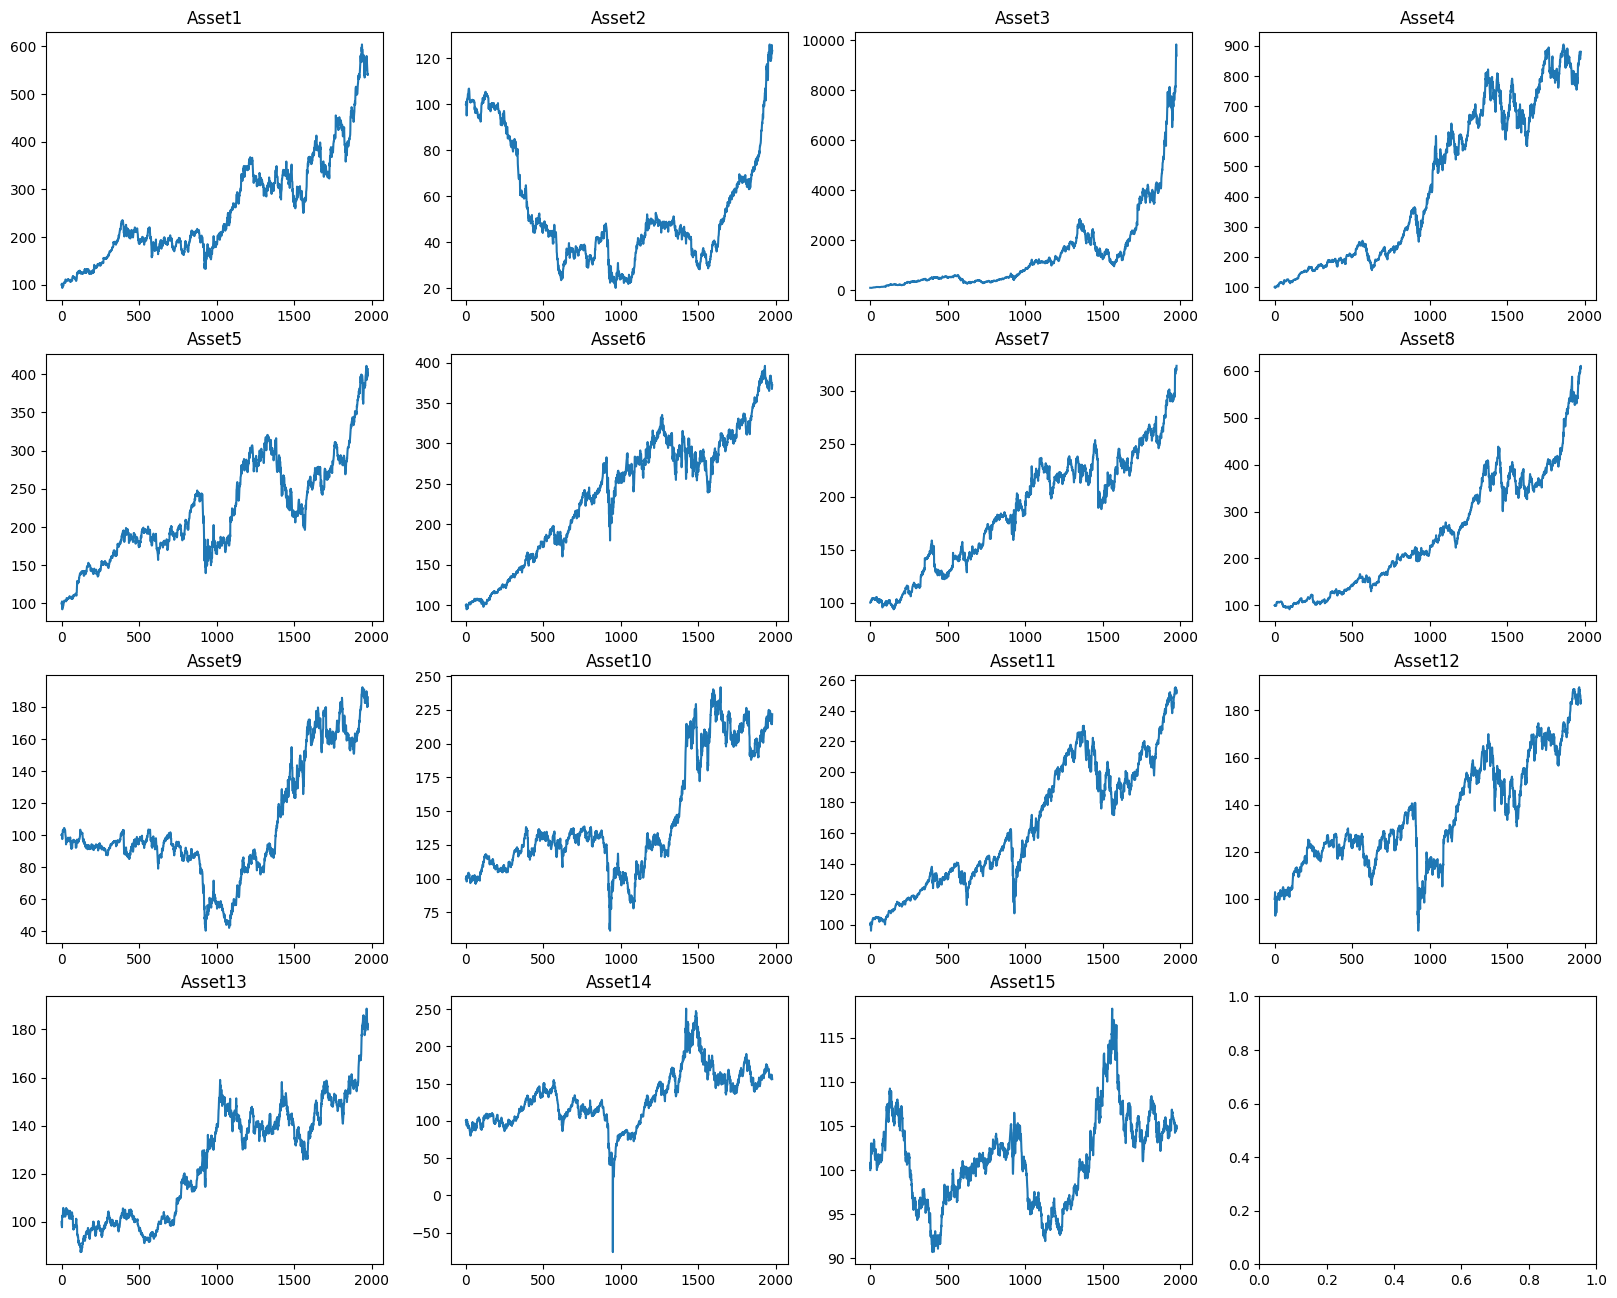

In [5]:
fig, ax = plt.subplots(4,4, figsize=(20,16))
j,k = 0,0
for i,asset in enumerate(prices.columns):
    ax[j,k].plot(prices[asset])
    ax[j,k].set_title(asset)
    if k < 3:
        k+=1
    else:
        k=0
        j+=1

**Matrice de corrélation entre les actifs**

Cette matrice permet de visualiser les co-mouvements des rendements.  
Dans la nouvelle version, on ne l'utilise plus comme filtre de décorrélation : la corrélation est directement intégrée dans la matrice de covariance utilisée par la vraie Risk Parity.

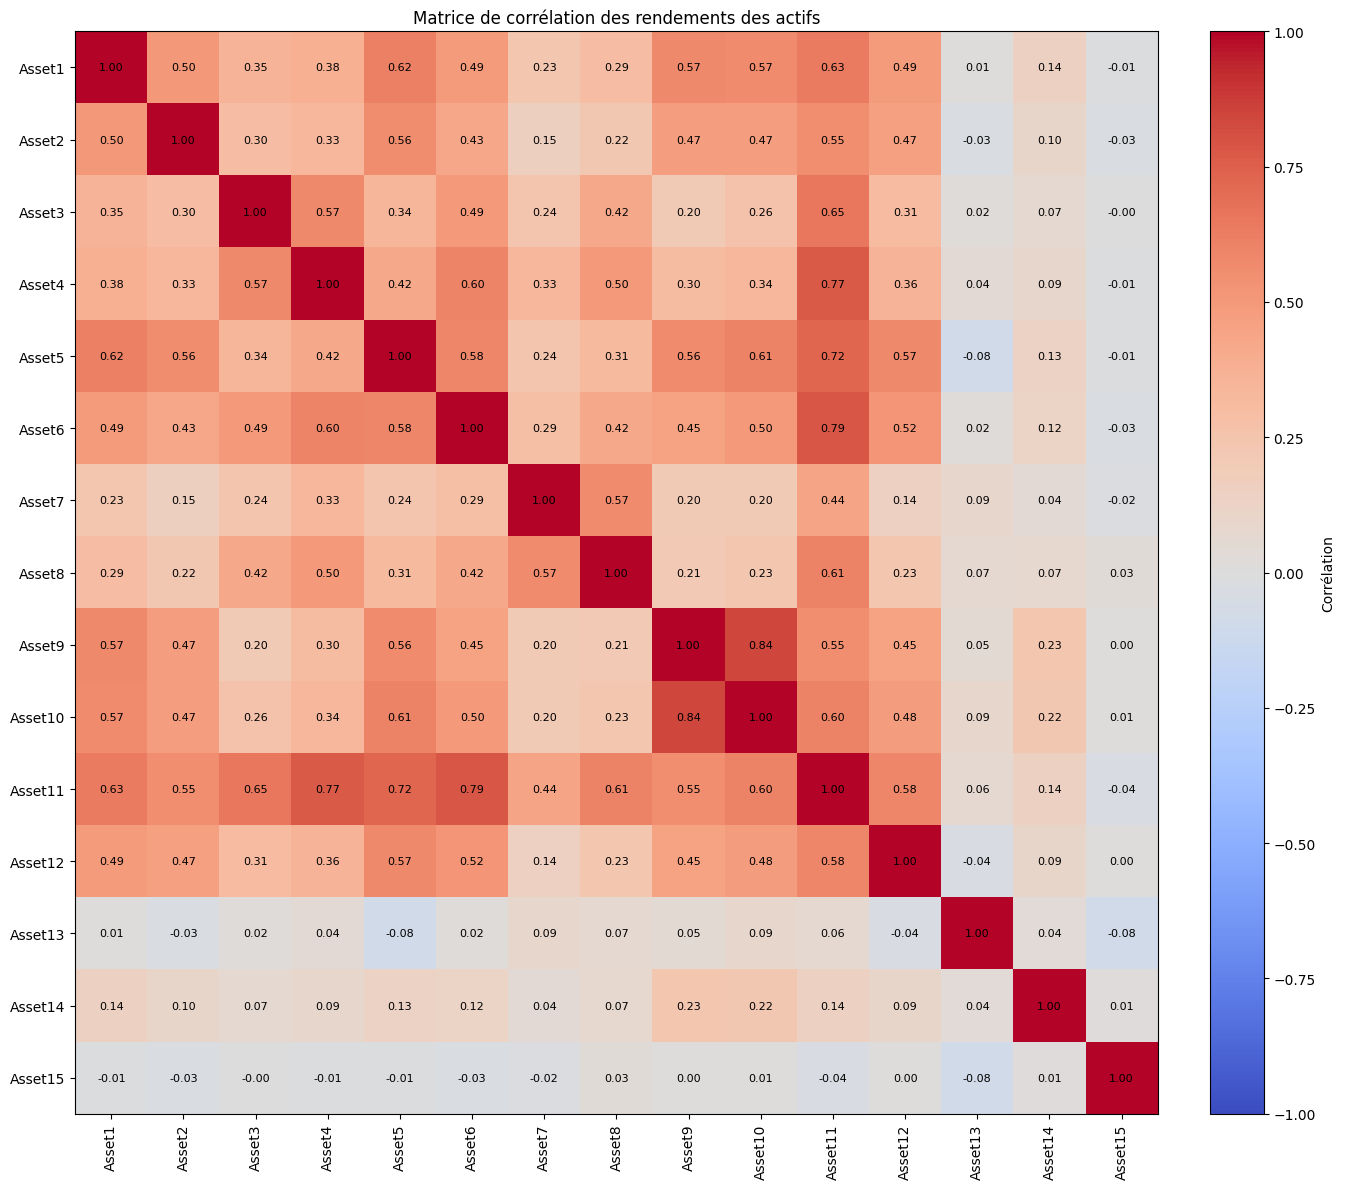

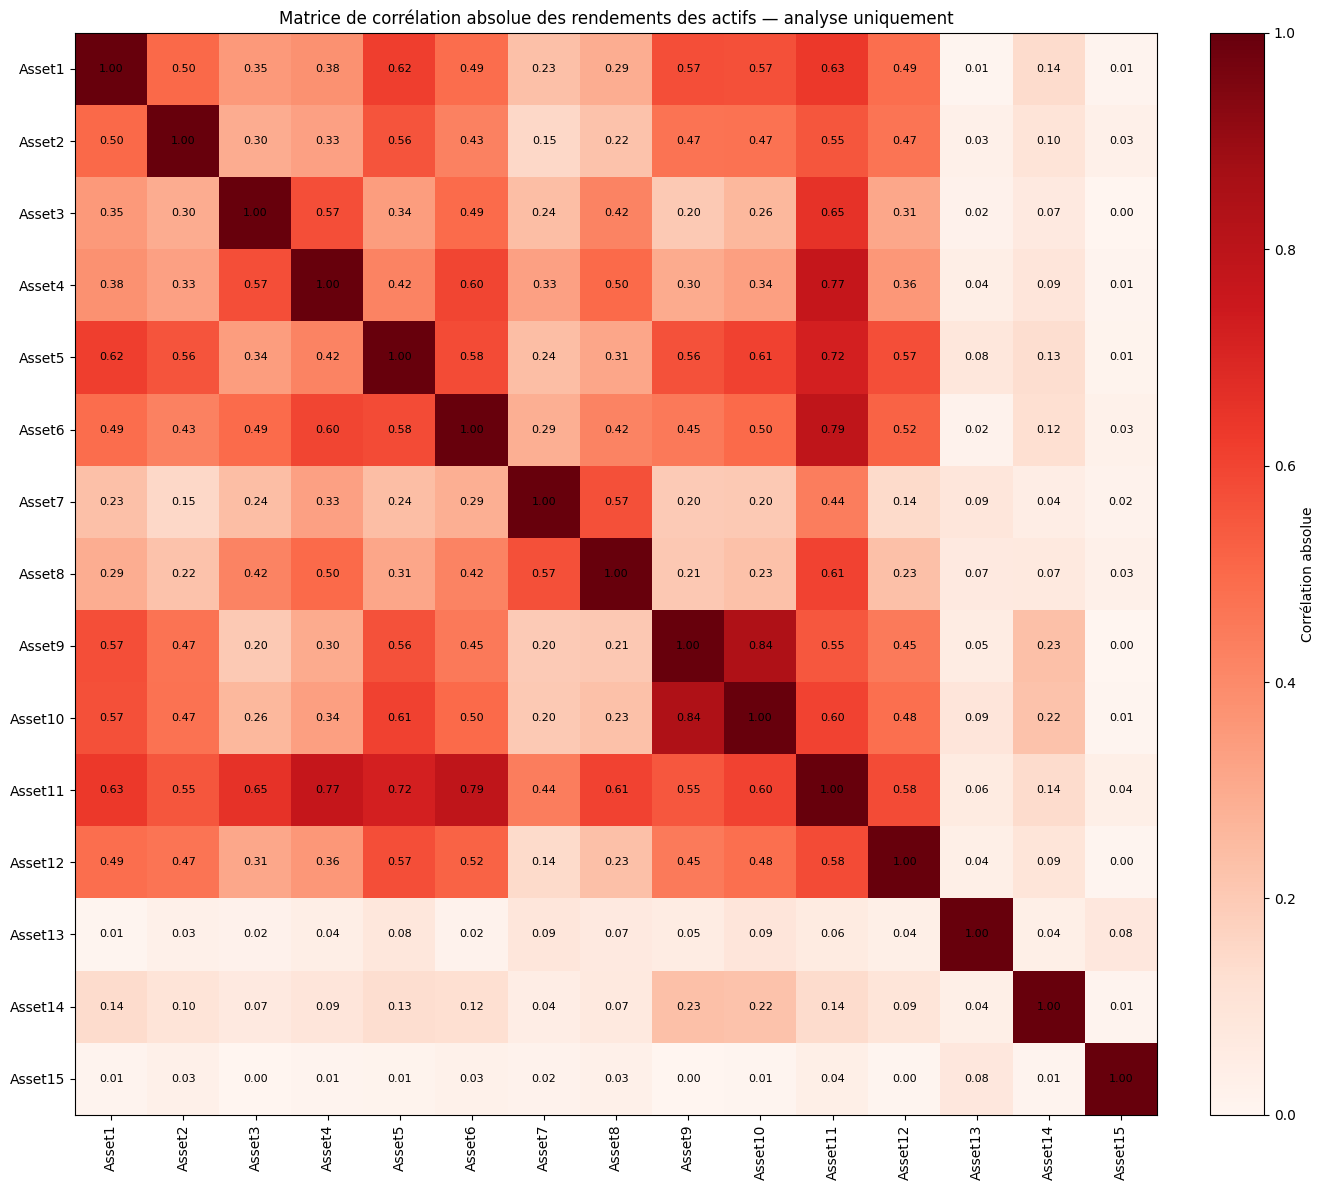

In [6]:
# Matrice de corrélation entre les actifs
# On utilise les rendements, pas les prix, car la corrélation doit mesurer les co-mouvements des variations.
asset_returns = prices.pct_change().dropna()
corr_assets = asset_returns.corr()

plt.figure(figsize=(14, 12))
im = plt.imshow(corr_assets, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im, fraction=0.046, pad=0.04, label="Corrélation")

plt.xticks(range(len(corr_assets.columns)), corr_assets.columns, rotation=90)
plt.yticks(range(len(corr_assets.index)), corr_assets.index)

# Affichage des valeurs dans chaque case
for i in range(len(corr_assets.index)):
    for j in range(len(corr_assets.columns)):
        plt.text(j, i, f"{corr_assets.iloc[i, j]:.2f}",
                 ha="center", va="center", fontsize=8)

plt.title("Matrice de corrélation des rendements des actifs")
plt.tight_layout()
plt.show()

# La corrélation absolue est conservée uniquement pour l'analyse visuelle.
# Elle n'est plus utilisée pour exclure des actifs.
abs_corr_assets = corr_assets.abs()

plt.figure(figsize=(14, 12))
im = plt.imshow(abs_corr_assets, vmin=0, vmax=1, cmap="Reds")
plt.colorbar(im, fraction=0.046, pad=0.04, label="Corrélation absolue")

plt.xticks(range(len(abs_corr_assets.columns)), abs_corr_assets.columns, rotation=90)
plt.yticks(range(len(abs_corr_assets.index)), abs_corr_assets.index)

for i in range(len(abs_corr_assets.index)):
    for j in range(len(abs_corr_assets.columns)):
        plt.text(j, i, f"{abs_corr_assets.iloc[i, j]:.2f}",
                 ha="center", va="center", fontsize=8)

plt.title("Matrice de corrélation absolue des rendements des actifs — analyse uniquement")
plt.tight_layout()
plt.show()


**Quelques fonctions de base**

In [7]:
def normalize_price(serie):
    '''
    -serie (pd.Serie) : série de prix
    Normalise la série avec le prix à t_0 = 100
    '''
    s = serie/serie.shift(1)
    s.iloc[0] = 100
    return s.cumprod()

def get_returns(df):
    '''
    -df (pd.DataFrame ou pd.Series) : dataframe ou série des prix
    Renvoie les returns
    '''
    return (df/df.shift(1)).dropna()

def get_cagr(serie):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    Cumulative Annual Growth Return
    '''
    return round(float(((serie.iloc[-1]/serie.iloc[0])**(1/(len(serie)/252))) - 1), 4)

def get_vol(serie):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    Annualized Volatility
    '''
    return round(float(get_returns(serie).std() * np.sqrt(252)), 4)

def get_sr(serie, r=0.0):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    -r (float) : taux d'intérêt (à 0 pour le projet)
    Annualized Sharpe Ratio
    '''
    return round(float((get_cagr(serie) - r) / get_vol(serie)), 4)

def get_calmar(serie):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    Calmar Ratio
    '''
    return round(get_cagr(serie)/get_mdd(serie), 4)

def get_mdd(serie):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    Max Drawdown
    '''
    running_max = np.maximum.accumulate(serie)
    drawdowns   = (serie - running_max) / running_max
    trough_idx  = int(np.argmin(drawdowns))
    mdd         = -drawdowns.iloc[trough_idx]
    return round(float(mdd), 4)

def get_corr(serie, benchmark):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    -benchmark (pd.Serie) : série de prix du benchmark (généralement S&P500)
    Correlation
    '''
    return round(float(np.corrcoef(get_returns(serie), get_returns(benchmark))[0,1]), 4)

def overall_score(serie, benchmark):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    -benchmark (pd.Serie) : série de prix du benchmark (généralement S&P500)
    Personnalized selection score
    '''
    return round((0.5*get_sr(serie) + 0.5*get_calmar(serie))/get_corr(serie, benchmark),4)

def compute_metrics(serie, benchmark):
    '''
    -serie (pd.Serie) : série de prix (asset ou portfolio)
    -benchmark (pd.Serie) : série de prix du benchmark (généralement S&P500)
    Compute all metrics
    '''
    print(f"CAGR : {round(get_cagr(serie) * 100, 4)} %")
    print(f"Annualized Vol : {round(get_vol(serie)* 100, 4)} %")
    print(f"Sharpe Ratio : {round(get_sr(serie), 4)}")
    print(f"Calmar Ratio : {round(get_calmar(serie), 4)}")
    print(f"Max Drawdown : {round(get_mdd(serie)*100,4)} %")
    print(f"Corr-bench : {round(float(get_corr(serie, benchmark)), 4)}")
    print(f"Overall score : {overall_score(serie, benchmark)}")

#### Fonction à compléter
La fonction doit prendre en entrée un dataframe de taille 252 (moins de données pourront être utilisées dans la fonction si nécessaire) et renvoyer un vecteur (np.array, shape (15,)) de taille 15 comprenant les poids des asset 1 à 15. Il y a deux contraintes sur le vecteur :

- Les poids sont positifs.

- La somme des poids est égale ou inférieure à 1


In [8]:
def risk_parity_weights(cov_matrix, tol=1e-10, max_iter=1000):
    """
    Calcule les poids Risk Parity "réels" / Equal Risk Contribution (ERC).

    Formule utilisée
    ----------------
    Soit Σ la matrice de covariance des rendements et w le vecteur de poids.

    Volatilité du portefeuille :
        σ_p = sqrt(w.T @ Σ @ w)

    Contribution marginale au risque :
        MRC_i = (Σw)_i / σ_p

    Contribution totale au risque de l'actif i :
        RC_i = w_i * MRC_i

    En Risk Parity, on cherche :
        RC_i = σ_p / n, pour tous les actifs i

    Contraintes :
        w_i >= 0
        sum(w_i) = 1

    Remarque importante :
    ---------------------
    Contrairement à l'inverse-volatilité simple, cette méthode utilise toute la
    matrice de covariance Σ. Elle prend donc en compte à la fois les volatilités
    individuelles et les corrélations entre actifs.
    """

    cov = np.asarray(cov_matrix, dtype=float)
    n = cov.shape[0]

    if n == 0:
        return np.array([])

    if n == 1:
        return np.array([1.0])

    # Nettoyage numérique
    cov = np.nan_to_num(cov, nan=0.0, posinf=0.0, neginf=0.0)
    cov = 0.5 * (cov + cov.T)  # sécurité : matrice symétrique

    # Petite régularisation pour éviter les matrices quasi singulières
    eps = 1e-8
    cov = cov + eps * np.eye(n)

    def portfolio_volatility(w):
        variance = float(w @ cov @ w)
        return np.sqrt(max(variance, 1e-16))

    def risk_contributions(w):
        sigma_p = portfolio_volatility(w)
        marginal_risk = cov @ w / sigma_p
        total_risk_contribution = w * marginal_risk
        return total_risk_contribution, sigma_p

    def objective(w):
        rc, sigma_p = risk_contributions(w)
        target_rc = sigma_p / n

        # On normalise par sigma_p^2 pour stabiliser l'optimisation.
        return np.sum((rc - target_rc) ** 2) / (sigma_p ** 2 + 1e-16)

    x0 = np.ones(n) / n

    constraints = {
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1.0
    }

    bounds = [(0.0, 1.0) for _ in range(n)]

    result = minimize(
        objective,
        x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "ftol": tol,
            "maxiter": max_iter,
            "disp": False
        }
    )

    # Fallback robuste : si l'optimisation échoue, on revient à l'inverse-volatilité.
    # Cela évite que la stratégie plante pendant le backtest.
    if (not result.success) or np.any(~np.isfinite(result.x)):
        vol = np.sqrt(np.maximum(np.diag(cov), eps))
        inv_vol = 1.0 / vol
        weights = inv_vol / inv_vol.sum()
    else:
        weights = np.maximum(result.x, 0.0)
        weights = weights / weights.sum()

    return weights


def compute_weights(df, max_assets=5, lookback_momentum=60, shrinkage=0.0):
    """
    Calcule les poids du portefeuille avec :
    1) un filtre momentum pour sélectionner les actifs les plus dynamiques,
    2) aucune règle de décorrélation manuelle,
    3) une vraie pondération Risk Parity / Equal Risk Contribution.

    Pourquoi on supprime le filtre de décorrélation ?
    -------------------------------------------------
    La Risk Parity réelle utilise la matrice de covariance des rendements.
    Cette matrice contient :
    - les volatilités individuelles des actifs,
    - les corrélations entre les actifs.

    Donc on n'a pas besoin d'exclure manuellement les actifs corrélés :
    l'optimisation ajuste les poids en fonction des contributions au risque.

    Paramètres
    ----------
    df : pd.DataFrame
        Fenêtre de prix des actifs.
    max_assets : int
        Nombre maximal d'actifs retenus après le classement momentum.
    lookback_momentum : int
        Nombre de jours utilisés pour calculer le momentum.
    shrinkage : float
        Intensité optionnelle de régularisation de la covariance.
        Par défaut, shrinkage = 0.0 : on utilise donc la covariance empirique complète,
        avec ses corrélations, sans filtre de décorrélation.

    Retour
    ------
    np.array
        Vecteur de poids positif, de somme <= 1, de taille len(df.columns).
    """

    prices_window = df.copy()
    returns = prices_window.pct_change().dropna()
    n_assets_total = len(df.columns)

    if len(prices_window) < 2 or returns.empty:
        return np.zeros(n_assets_total)

    lookback = min(lookback_momentum, len(prices_window) - 1)

    # Momentum : performance récente de chaque actif
    momentum = prices_window.iloc[-1] / prices_window.iloc[-lookback] - 1
    momentum = momentum.replace([np.inf, -np.inf], np.nan).dropna()

    # On garde seulement les actifs avec un momentum positif
    momentum = momentum[momentum > 0]

    if len(momentum) == 0:
        return np.zeros(n_assets_total)

    # Sélection simple : top actifs par momentum.
    # Pas de filtre de corrélation ici.
    selected_assets = momentum.sort_values(ascending=False).head(max_assets).index.tolist()

    if len(selected_assets) == 0:
        return np.zeros(n_assets_total)

    selected_returns = returns[selected_assets].dropna(how="all")

    # Matrice de covariance des rendements sélectionnés.
    # C'est ici que les corrélations sont prises en compte.
    cov = selected_returns.cov().values

    # Par défaut, on garde la covariance empirique complète.
    # Si shrinkage > 0, on applique une régularisation optionnelle vers la diagonale.
    # Ici, avec shrinkage = 0.0, aucune décorrélation manuelle n'est appliquée.
    if shrinkage > 0:
        diag_cov = np.diag(np.diag(cov))
        cov = (1.0 - shrinkage) * cov + shrinkage * diag_cov

    selected_weights = risk_parity_weights(cov)

    final_weights = pd.Series(0.0, index=df.columns)
    final_weights.loc[selected_assets] = selected_weights

    # Sécurité finale pour respecter les contraintes du challenge
    final_weights = final_weights.clip(lower=0.0)
    if final_weights.sum() > 1.0:
        final_weights = final_weights / final_weights.sum()

    return final_weights.values


#### Benchmark Simple - Equally weighted
Une méthode simple de répartition des poids serait de répartir la valeur du portefeuille de manière équipondérée

In [9]:
eq_weighted_portfolio = normalize_price(((prices*1/15).sum(axis=1)).iloc[K:])

**Fonction permettant de valider les poids**

In [10]:
def check_weights(w):
    '''
    -w (np.array, shape : (15,)) : Vecteur des poids
    Renvoie False si les poids ne respectent pas les contraintes
    '''
    if round(w.sum(), 3)<=1 and (w<0).sum()==0:
        return True
    else:
        print("Poids négatifs ou somme supérieure à 1")
        print(f"Poids {w}")
        print(f"Somme : {w.sum()}")
        return False

**Chargement des autres benchmark**

In [11]:
# Chargement robuste : fonctionne avec les noms originaux du sujet ou avec les fichiers uploadés ici.
try:
    df_benchmark = pd.read_csv("df_benchmark.csv", sep=";", index_col=0)
except FileNotFoundError:
    df_benchmark = pd.read_csv("df_benchmark(1).csv", sep=";", index_col=0)

secret_bench = normalize_price(df_benchmark["Secret"])
sp500 = normalize_price(df_benchmark["SP500"])


**Backtest la stratégie**

In [12]:
def backtest():
    # Calculate Weights
    weights_t = []
    for i in range(len(prices) - K + 1):
        w = compute_weights(prices.iloc[i:i + K])
        if check_weights(w):
            weights_t.append(w)
        else:
            break

    weights_array = np.array(weights_t)

    # Calculate portfolio value and returns
    pr = (weights_array[1:-1] * get_returns(prices).iloc[K:]).sum(axis=1)

    portfolio = [100]
    for i in range(len(pr)):
        portfolio.append(pr.iloc[i] * portfolio[-1])

    portfolio = pd.Series(portfolio)
    portfolio.index = sp500.index

    print("==========PORTFOLIO===========")
    compute_metrics(portfolio, sp500)
    print("==========S&P500==============")
    compute_metrics(sp500, sp500)
    print("==========EQ-WEIGHTED=========")
    compute_metrics(eq_weighted_portfolio, sp500)
    print("======SECRET-BENCHMARK========")
    compute_metrics(secret_bench, sp500)

    # Courbe de performance
    plt.figure(figsize=(20, 12))
    plt.plot(portfolio)
    plt.plot(sp500)
    plt.plot(eq_weighted_portfolio)
    plt.plot(secret_bench)
    plt.legend(["Portfolio", "S&P500", "Eq-Weighted", "Secret"])
    plt.title("Évolution de la performance du portefeuille")
    plt.xlabel("Date")
    plt.ylabel("Valeur normalisée")
    plt.grid(True)

    # ========= Courbe d'évolution des poids =========
    # Les poids utilisés pour calculer les rendements commencent à weights_array[1:-1].
    weights_df = pd.DataFrame(
        weights_array[1:-1],
        index=get_returns(prices).iloc[K:].index,
        columns=prices.columns
    )

    plt.figure(figsize=(20, 12))
    for asset in weights_df.columns:
        plt.plot(weights_df.index, weights_df[asset], label=asset)

    plt.title("Évolution des poids des actifs dans le portefeuille")
    plt.xlabel("Date")
    plt.ylabel("Poids")
    plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
    plt.grid(True)
    plt.tight_layout()

    return portfolio


==========PORTFOLIO===========
CAGR : 26.0 %
Annualized Vol : 16.72 %
Sharpe Ratio : 1.555
Calmar Ratio : 1.0459
Max Drawdown : 24.86 %
Corr-bench : 0.5891
Overall score : 2.2075
==========S&P500==============
CAGR : 11.94 %
Annualized Vol : 19.6 %
Sharpe Ratio : 0.6092
Calmar Ratio : 0.352
Max Drawdown : 33.92 %
Corr-bench : 1.0
Overall score : 0.4806
==========EQ-WEIGHTED=========
CAGR : 33.58 %
Annualized Vol : 25.45 %
Sharpe Ratio : 1.3194
Calmar Ratio : 0.951
Max Drawdown : 35.31 %
Corr-bench : 0.8547
Overall score : 1.3282
======SECRET-BENCHMARK========
CAGR : 13.43 %
Annualized Vol : 13.37 %
Sharpe Ratio : 1.0045
Calmar Ratio : 0.6025
Max Drawdown : 22.29 %
Corr-bench : 0.7172
Overall score : 1.1203


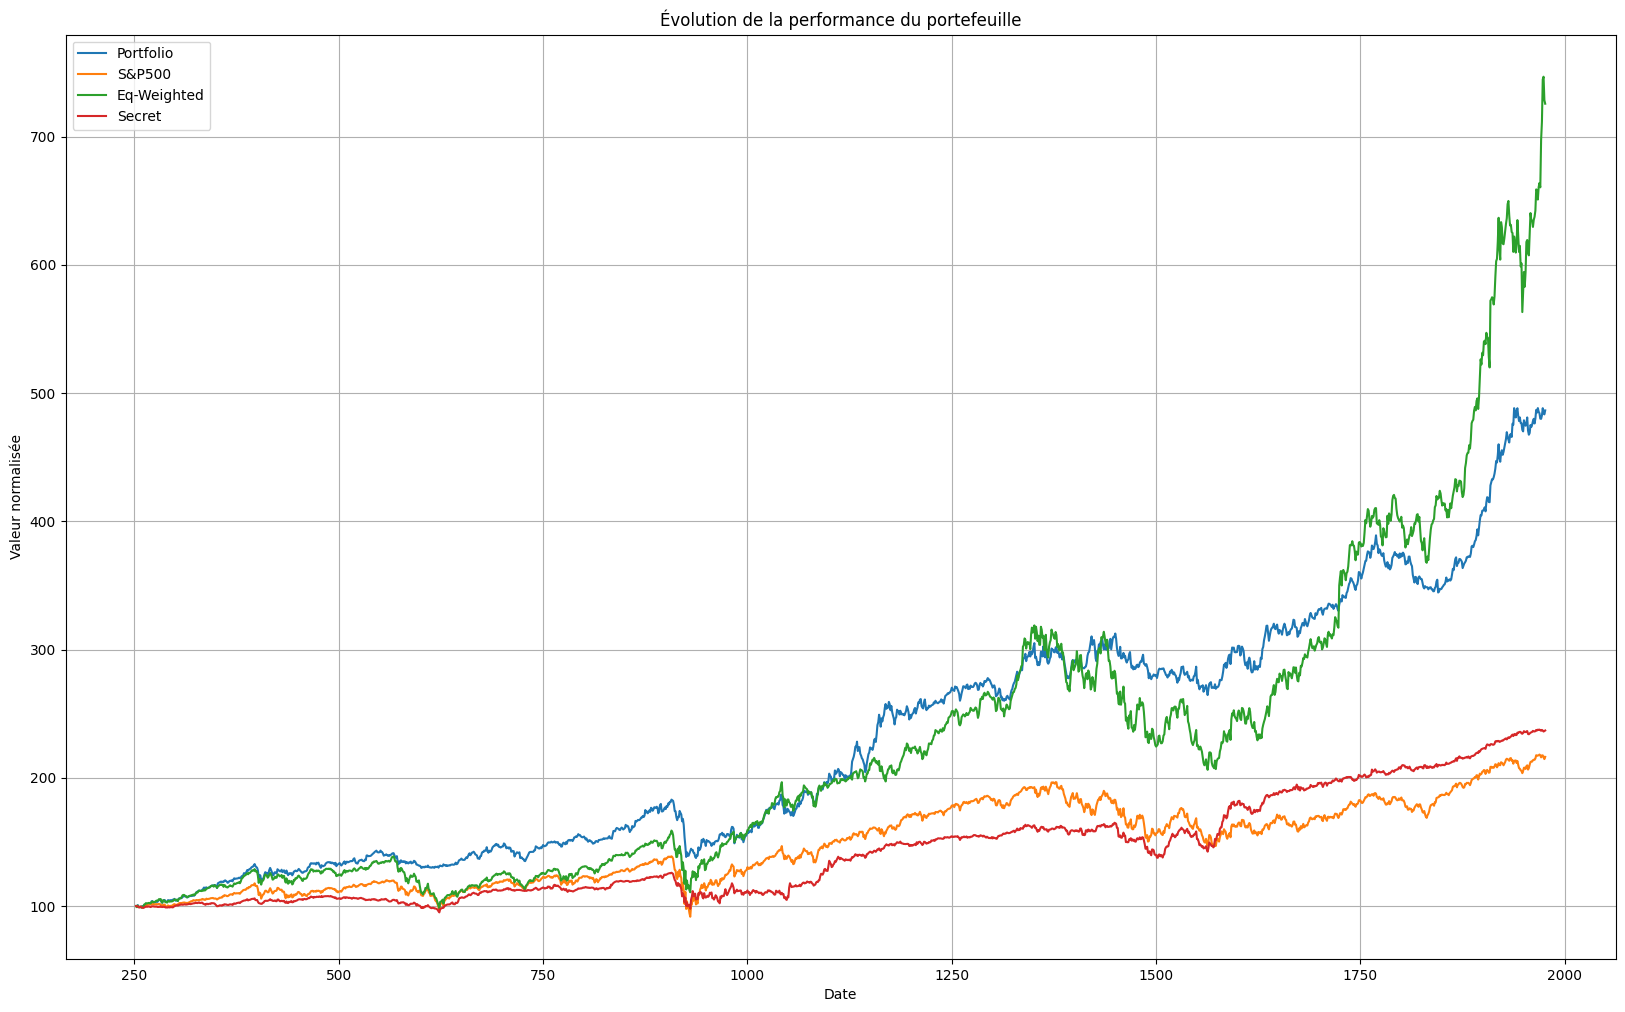

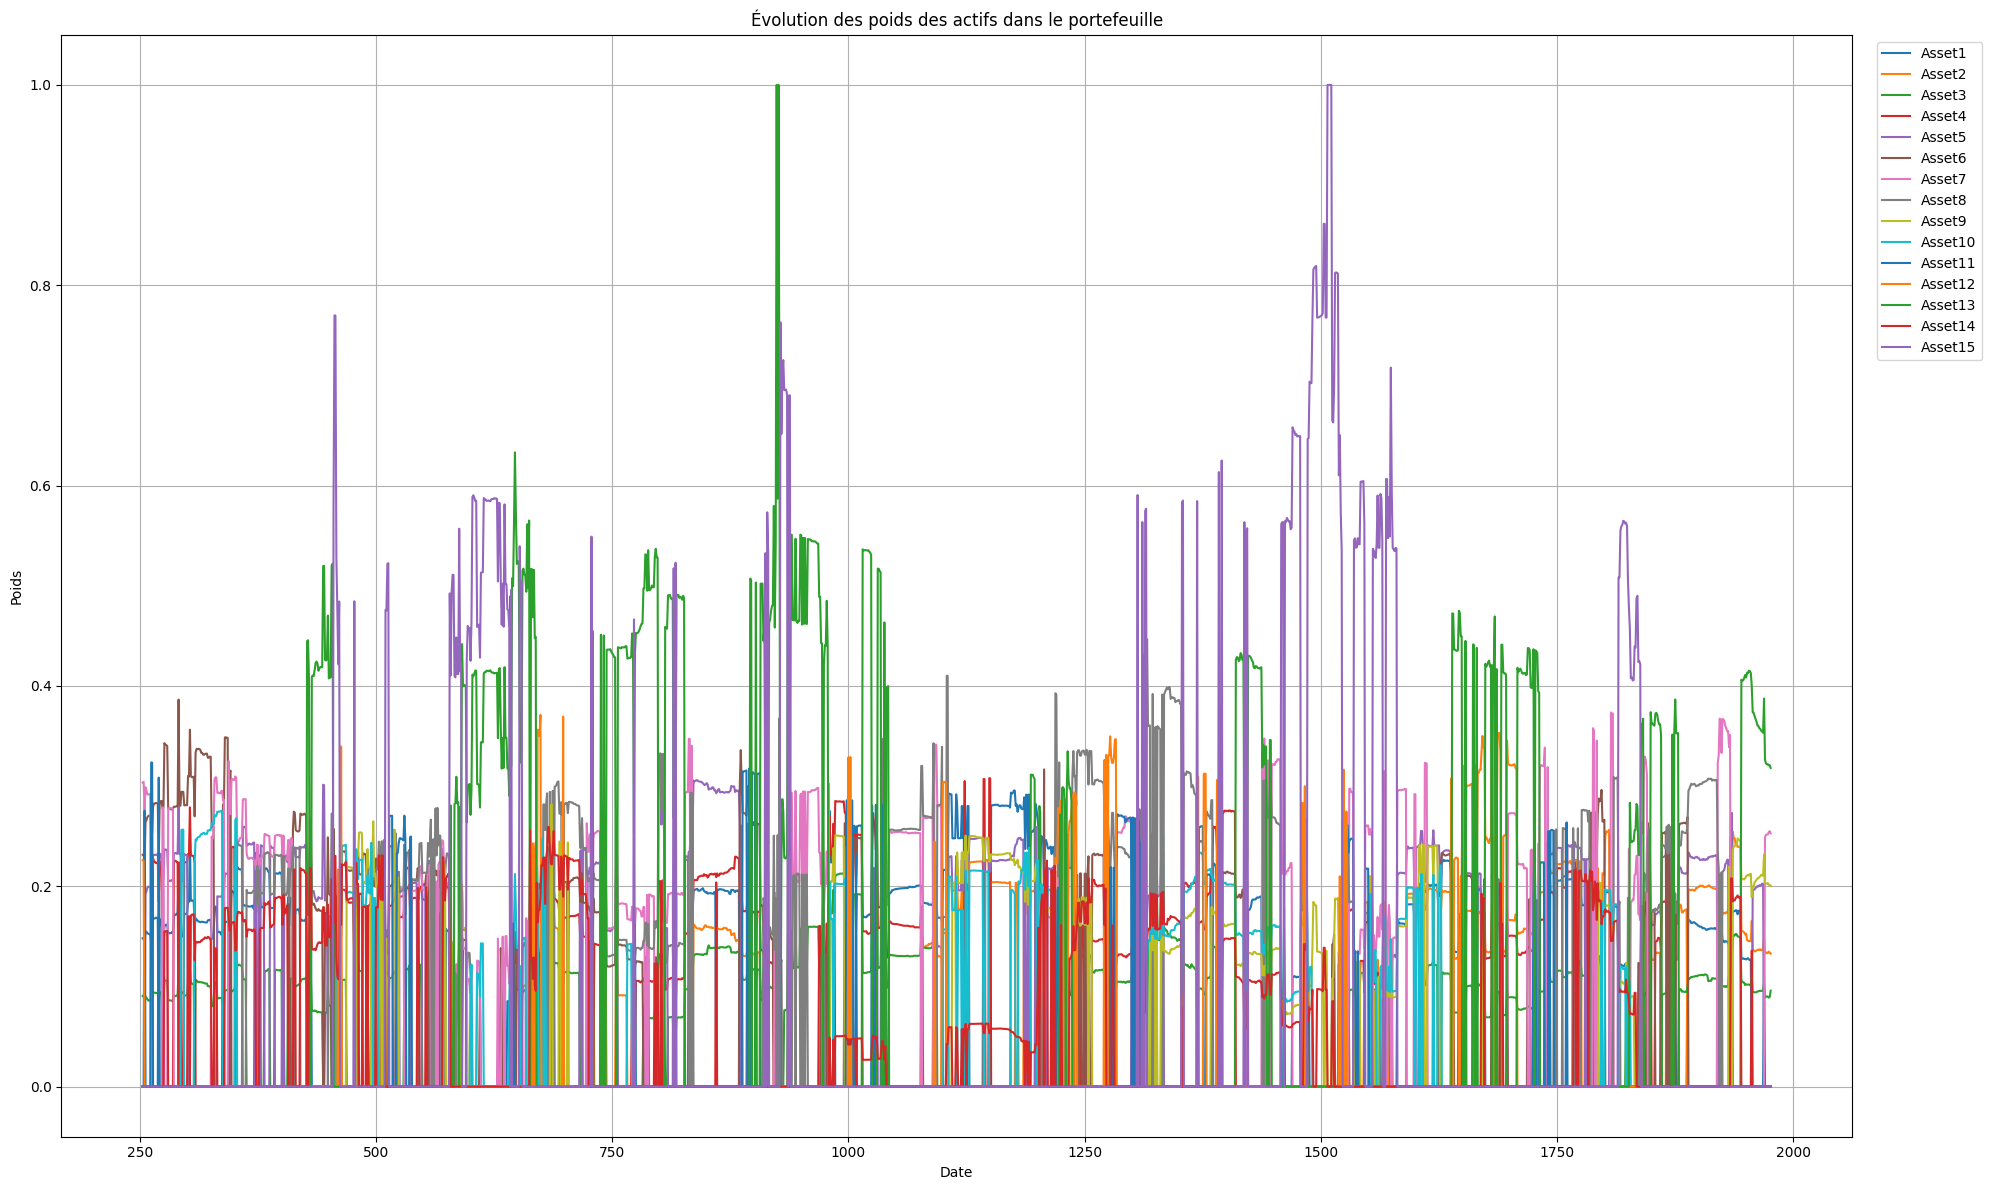

In [13]:
strat1 = backtest()
